# Tarea 7: Clasificación de Texto con Naive Bayes
## Análisis de Sentimiento en Reseñas de Películas

**Nombre:** Manuel Elias Orellana Lavayen

**Fecha:** 17/6/2026

### Objetivo:
Familiarizar al estudiante con el algoritmo Naive Bayes para clasificación de texto, aplicando técnicas de preprocesamiento como Bag of Words (CountVectorizer) y TF-IDF, analizando el efecto de hiperparámetros como `alpha` (suavizado Laplaciano) y n-gramas, y evaluando el modelo mediante métricas de precisión, recall y F1-score.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.
6. NO ELIMINAR NINGÚN COMENTARIO

### Descripción del Dataset:
Utilizaremos el dataset **Rotten Tomatoes Movie Reviews** que contiene reseñas de críticos de cine. Cada reseña está clasificada como:
- **fresh**: Reseña positiva
- **rotten**: Reseña negativa

### Archivo requerido:
- `critics.csv` - Dataset de reseñas de películas

## Parte 1: Configuración y Carga de Datos

In [217]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [218]:
# TODO: Cargar el dataset critics.csv
#
# Instrucciones:
# 1. Use pd.read_csv('critics.csv') para cargar el dataset
# 2. Imprima las dimensiones con .shape
# 3. Imprima los nombres de columnas
# 4. Muestre las primeras filas con .head()

df_critics = pd.read_csv("critics.csv")
print("Dimensiones del dataset: ", df_critics.shape)
print("Nombres de columnas: ", list(df_critics.columns))
df_critics.head(7)

Dimensiones del dataset:  (27631, 8)
Nombres de columnas:  ['critic', 'fresh', 'imdb', 'publication', 'quote', 'review_date', 'rtid', 'title']


,critic,fresh,imdb,publication,quote,review_date,rtid,title
0,Owen Gleiberman,fresh,114709,Entertainment Weekly,NaN,2011-09-07,9559,Toy story
1,Derek Adams,fresh,114709,Time Out,"So ingenious in concept, design and execution ...",2009-10-04,9559,Toy story
2,Richard Corliss,fresh,114709,TIME Magazine,The year's most inventive comedy.,2008-08-31,9559,Toy story
3,David Ansen,fresh,114709,Newsweek,A winning animated feature that has something ...,2008-08-18,9559,Toy story
4,Leonard Klady,fresh,114709,Variety,The film sports a provocative and appealing st...,2008-06-09,9559,Toy story
5,Jonathan Rosenbaum,fresh,114709,Chicago Reader,"An entertaining computer-generated, hyperreali...",2008-03-10,9559,Toy story
6,Michael Booth,fresh,114709,Denver Post,"As Lion King did before it, Toy Story revived ...",2007-05-03,9559,Toy story


In [219]:
# TODO: Limpiar el dataset
#
# Instrucciones:
# 1. Elimine filas con quotes nulos: critics = critics[~critics.quote.isnull()]
# 2. Filtre solo fresh y rotten: critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
# 3. Imprima las dimensiones después de limpiar

#Simplemente elimina las filas con nulos en columna "quote", en lo personal considero que df.dropna(subset=['quote']) es mas intuitivo
df_critics = df_critics[~df_critics.quote.isnull()] #El simbolo "~" sirve para intercambiar el valo booleano de toda una columna
df_critics = df_critics[df_critics["fresh"].isin(['fresh', 'rotten'])] #FIltra y asegura que en la columna fresh solo hayan dos tipos de valores
print("Dimensiones: ", df_critics.shape)

Dimensiones:  (15534, 8)


### Pregunta 1: Tamaño del Dataset
¿Cuántas reseñas válidas quedan después de limpiar el dataset?

A) Aproximadamente 5,000  
B) Aproximadamente 10,000  
C) Aproximadamente 15,000  
D) Aproximadamente 20,000  

**Su Respuesta:** C

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [220]:
# TODO: Explorar estadísticas básicas
#
# Instrucciones:
# 1. Calcule n_reviews = len(critics)
# 2. Calcule n_movies = critics.rtid.nunique()
# 3. Calcule n_critics = critics.critic.nunique()
# 4. Imprima las estadísticas

n_filas = len(df_critics)
n_peliculas = df_critics["rtid"].nunique()
n_criticas = df_critics["critic"].nunique()
print(f"Filas: {n_filas}, \n"
      f"Peliculas: {n_peliculas}, \n"
      f"Criticas: {n_criticas}")

Filas: 15534, 
Peliculas: 1921, 
Criticas: 621


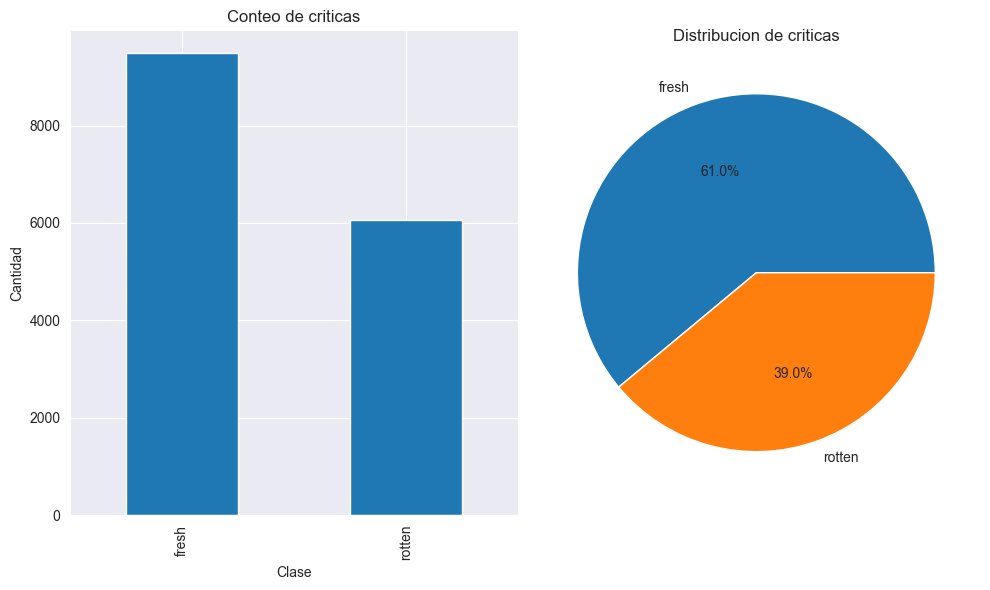

El conteo de las clases de flesh es: 
fresh
fresh     9482
rotten    6052
Name: count, dtype: int64


In [221]:
# TODO: Visualizar distribución de clases
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use critics['fresh'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use .plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas
# 5. Imprima el conteo de clases

n_clases = df_critics["fresh"].value_counts()

figura, axes = plt.subplots(nrows= 1, ncols= 2)

n_clases.plot(kind='bar', ax= axes[0])
axes[0].set_title("Conteo de criticas")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad")

n_clases.plot(kind='pie', autopct='%1.1f%%', ax= axes[1])
axes[1].set_title("Distribucion de criticas")
axes[1].set_ylabel("") #Para quitar el colocado automatico

# Ajustar espacios
plt.tight_layout()
plt.show()

print("El conteo de las clases de flesh es: ")
print(n_clases)

### Pregunta 2: Balance de Clases
¿Cuál es la clase mayoritaria en el dataset?

A) rotten (negativas)  
B) fresh (positivas)  
C) Están perfectamente balanceadas  
D) No se puede determinar  

**Su Respuesta:** B

In [222]:
# TODO: Analizar longitud de las reseñas
#
# Instrucciones:
# 1. Cree una columna 'quote_length' con la longitud de cada quote: critics['quote'].apply(len)
# 2. Cree una columna 'word_count' con el número de palabras: critics['quote'].apply(lambda x: len(str(x).split()))
# 3. Imprima estadísticas descriptivas de estas columnas
# 4. Opcional: Cree histogramas comparando fresh vs rotten

df_critics['quote_length'] = df_critics["quote"].apply(len)
df_critics['word_count'] = df_critics["quote"].apply(func= lambda x: len(str(x).split()))
print(df_critics['quote_length'].describe())
print()
print(df_critics['word_count'].describe())

count    15534.000000
mean       117.014484
std         57.581577
min          4.000000
25%         72.000000
50%        114.000000
75%        158.000000
max        256.000000
Name: quote_length, dtype: float64

count    15534.000000
mean        19.447534
std          9.792644
min          1.000000
25%         12.000000
50%         19.000000
75%         26.000000
max         49.000000
Name: word_count, dtype: float64


In [223]:
# TODO: Mostrar ejemplos de reseñas
#
# Instrucciones:
# 1. Imprima 3 ejemplos de reseñas 'fresh' usando critics[critics['fresh']=='fresh']['quote'].head(3)
# 2. Imprima 3 ejemplos de reseñas 'rotten'

#Aplica filtro booleano y luego con ["quote"] solo se muestra la columna quote
print("Ejemplos con 'fresh': \n")
print(df_critics[df_critics["fresh"] == "fresh"]["quote"].head(3))
print("\n")
print("Ejemplos con 'rotten': \n")
print(df_critics[df_critics["fresh"] == "rotten"]["quote"].head(3))


Ejemplos con 'fresh': 

1    So ingenious in concept, design and execution ...
2                    The year's most inventive comedy.
3    A winning animated feature that has something ...
Name: quote, dtype: object


Ejemplos con 'rotten': 

30    A gloomy special-effects extravaganza filled w...
37                               Mediocre, regrettably.
40    The movie is too pat and practiced to really b...
Name: quote, dtype: object


## Parte 3: Preprocesamiento de Texto - Bag of Words

### Teoría:
El modelo **Bag of Words (BoW)** representa el texto como un vector de frecuencias de palabras, ignorando el orden. **CountVectorizer** de Scikit-Learn implementa este enfoque.

$$\text{Vector} = [\text{count}(w_1), \text{count}(w_2), ..., \text{count}(w_n)]$$

In [224]:
# TODO: Crear una función para preparar los datos
#
# Instrucciones:
# 1. Defina la función make_xy(data, vectorizer) que:
#    a. Aplique vectorizer.fit_transform(data['quote']) para obtener X
#    b. Convierta 'fresh' a binario: y = (data['fresh'] == 'fresh').astype(int).values
#    c. Retorne X, y

def make_xy(data, vectorizer):
    """Prepara los datos para el modelo."""
    # Su código aquí
    x= vectorizer.fit_transform(raw_documents= data['quote'])
    y = (data['fresh'] == 'fresh').astype(int).values #(data['fresh'] == 'fresh') Todo lo que sea True con astype lo hace "1"
    return x, y

In [225]:
# TODO: Aplicar CountVectorizer
#
# Instrucciones:
# 1. Cree vectorizer = CountVectorizer(min_df=5)
# 2. Use make_xy() para obtener X, y
# 3. Imprima la forma de X y y
# 4. Imprima algunos ejemplos de palabras del vocabulario con vectorizer.get_feature_names_out()[:20]

vectorizador = CountVectorizer(min_df=5)
x_general, y_general = make_xy(data= df_critics, vectorizer= vectorizador)
print(f"Dimension x: {x_general.shape}, la cantidad de columnas se debe a el vectorizador ")
print(f"Dimension y: {y_general.shape}")

vectorizador.get_feature_names_out()[800:840]

Dimension x: (15534, 6166), la cantidad de columnas se debe a el vectorizador 
Dimension y: (15534,)


array(['can', 'canadian', 'candidate', 'candy', 'cannot', 'canon',
       'canvas', 'capable', 'capacity', 'caper', 'capers', 'capital',
       'capote', 'capra', 'capsule', 'captain', 'captivating', 'capture',
       'captured', 'captures', 'capturing', 'car', 'card', 'cardboard',
       'care', 'career', 'careers', 'careful', 'carefully', 'cares',
       'caricature', 'caring', 'carnage', 'caro', 'carpenter', 'carrey',
       'carrie', 'carried', 'carries', 'carry'], dtype=object)

### Pregunta 3: Dimensiones del Vocabulario
¿Aproximadamente cuántas características (palabras únicas) tiene el vocabulario con min_df=5?

A) 500-1,000  
B) 1,000-5,000  
C) 5,000-10,000  
D) 10,000-20,000  

**Su Respuesta:** C

In [226]:
# TODO: Dividir en train y test
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.3, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
# 4. Imprima la distribución de clases en entrenamiento

x_entrenamiento_general, x_validacion_general, y_entrenamiento_general, y_validacion_general = train_test_split(x_general, y_general,  test_size=0.3, random_state=42)
print("Tamaño:")
print(f"x_entrenamiento: {x_entrenamiento_general.shape}")
print(f"y_entrenamiento: {y_entrenamiento_general.shape}")
print(f"x_validacion: {x_validacion_general.shape}")
print(f"y_validacion: {y_validacion_general.shape}")
print()
print("Distribucion de clases en entrenamiento: ")
print(pd.Series(data= y_entrenamiento_general).value_counts())
print("Donde:  1 es 'fresh' y 0 es 'rotten'")

Tamaño:
x_entrenamiento: (10873, 6166)
y_entrenamiento: (10873,)
x_validacion: (4661, 6166)
y_validacion: (4661,)

Distribucion de clases en entrenamiento: 
1    6623
0    4250
Name: count, dtype: int64
Donde:  1 es 'fresh' y 0 es 'rotten'


## Parte 4: Naive Bayes Multinomial

### Teoría - Teorema de Bayes:
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Naive Bayes** asume independencia condicional entre características:
$$P(X|C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

**Multinomial Naive Bayes** es apropiado para conteos de palabras.

In [227]:
# TODO: Entrenar Multinomial Naive Bayes
#
# Instrucciones:
# 1. Cree el modelo: clf_nb = MultinomialNB()
# 2. Entrene con clf_nb.fit(X_train, y_train)
# 3. Prediga en train y test
# 4. Calcule y muestre las precisiones en train y test con accuracy_score()

modelo_clasificador_multinomial= MultinomialNB()
modelo_clasificador_multinomial.fit(X= x_entrenamiento_general, y= y_entrenamiento_general) #No es necesario tranformarlo a array, ya que eso solo es con gausiano
y_predicciones_entrenamiento_multinomial = modelo_clasificador_multinomial.predict(X= x_entrenamiento_general)
y_predicciones_validacion_multinomial = modelo_clasificador_multinomial.predict(X= x_validacion_general)
print(f"Conjunto de entrenamiento: {accuracy_score(y_true= y_entrenamiento_general, y_pred= y_predicciones_entrenamiento_multinomial)}")
print(f"Conjunto de validacion: {accuracy_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial)}")

Conjunto de entrenamiento: 0.8708728041938747
Conjunto de validacion: 0.7670027891010512


### Pregunta 4: Precisión del Modelo Base
¿Cuál es la precisión aproximada del modelo Naive Bayes en el conjunto de prueba?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 5: Matriz de Confusión y Métricas

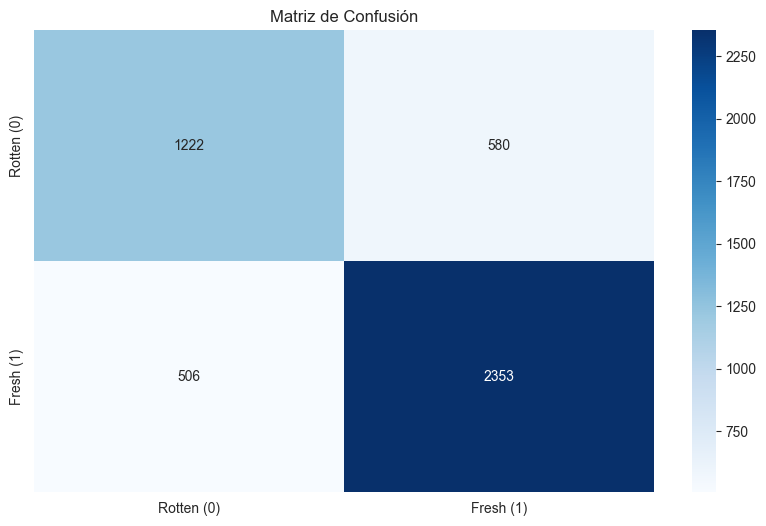

TN:  1222
FP:  580
FN:  506
TP:  2353


In [228]:
# TODO: Calcular y visualizar la matriz de confusión
#
# Instrucciones:
# 1. Calcule cm = confusion_matrix(y_test, y_pred_test)
# 2. Visualice con sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# 3. Configure xticklabels y yticklabels como ['Rotten (0)', 'Fresh (1)']
# 4. Imprima TN, FP, FN, TP


matriz_confusion_multinomial = confusion_matrix(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial)
sns.heatmap(data= matriz_confusion_multinomial, annot= True, fmt= "d", cmap= "Blues", xticklabels=['Rotten (0)', 'Fresh (1)'], yticklabels= ['Rotten (0)', 'Fresh (1)'])
plt.title('Matriz de Confusión')
plt.show()

TN, FP, FN, TP = matriz_confusion_multinomial.ravel()
print("TN: ", TN)
print("FP: ", FP)
print("FN: ", FN)
print("TP: ", TP)


In [229]:
# TODO: Calcular métricas detalladas
#
# Instrucciones:
# 1. Calcule precision = precision_score(y_test, y_pred_test)
# 2. Calcule recall = recall_score(y_test, y_pred_test)
# 3. Calcule f1 = f1_score(y_test, y_pred_test)
# 4. Imprima las métricas
# 5. Use classification_report() para el reporte completo
precision_rotten_multinomial= precision_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, pos_label= 0) #rotten
recall_rotten_multinomial = recall_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, pos_label= 0)
f1_rotten_multinomial = f1_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, pos_label= 0)
metricas_rotten_multinomial = pd.DataFrame(data= [[precision_rotten_multinomial, recall_rotten_multinomial, f1_rotten_multinomial]], columns=[["precision", "recall", "f1"]], index= ["Rotten"]).T

precision_fresh_multinomial = precision_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, pos_label= 1) #rotten
recall_fresh_multinomial = recall_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, pos_label= 1)
f1_fresh_multinomial = f1_score(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, pos_label= 1)
metricas_fresh_multinomial = pd.DataFrame(data= [[precision_fresh_multinomial, recall_fresh_multinomial, f1_fresh_multinomial]], columns=[["precision", "recall", "f1"]], index= ["Fresh"]).T

metricas = pd.concat(objs=[metricas_rotten_multinomial, metricas_fresh_multinomial], axis= 1)
reporte_clasificacion_multinomial = classification_report(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, target_names= ["Rotten", "Fresh"])
print(reporte_clasificacion_multinomial)
metricas

              precision    recall  f1-score   support

      Rotten       0.71      0.68      0.69      1802
       Fresh       0.80      0.82      0.81      2859

    accuracy                           0.77      4661
   macro avg       0.75      0.75      0.75      4661
weighted avg       0.77      0.77      0.77      4661



,Rotten,Fresh
precision,0.707176,0.802250
recall,0.678135,0.823015
f1,0.692351,0.812500


### Pregunta 5: Interpretación de Métricas
Si el modelo tiene alto recall pero baja precisión para la clase 'Fresh', ¿qué significa?

A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  
B) El modelo no detecta las reseñas positivas  
C) El modelo es perfecto  
D) El modelo solo predice negativas  

**Su Respuesta:** A

## Parte 6: Efecto del Parámetro Alpha (Suavizado Laplaciano)

### Teoría:
El parámetro `alpha` es el **suavizado de Laplace** (additive smoothing). Evita probabilidades de cero para palabras no vistas:

$$P(w|C) = \frac{\text{count}(w,C) + \alpha}{\text{count}(C) + \alpha \cdot |V|}$$

- alpha=1.0: Suavizado estándar (default)
- alpha<1.0: Menos suavizado
- alpha>1.0: Más suavizado

In [230]:
# TODO: Experimentar con diferentes valores de alpha
#
# Instrucciones:
# 1. Defina alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# 2. Para cada alpha:
#    a. Cree MultinomialNB(alpha=alpha)
#    b. Entrene y calcule precisiones train/test
#    c. Calcule precision y recall
# 3. Guarde resultados en un DataFrame e imprima

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
modelos_alphas = []
preciciones_entrenamiento_alphas  = []
preciciones_validacion_alphas  = []
recalls_entrenamiento_alphas  = []
recalls_validacion_alphas  = []
exactitudes_entrenamiento_alphas  = []
exactitudes_validacion_alphas  = []

for alpha in alphas:
    modelo_alpha = MultinomialNB(alpha= alpha)
    modelo_alpha.fit(X= x_entrenamiento_general, y= y_entrenamiento_general)

    y_prediciones_entrenamiento_alpha  = modelo_alpha.predict(X= x_entrenamiento_general)
    y_prediciones_validacion_alpha  = modelo_alpha.predict(X= x_validacion_general)

    precision_entrenamiento_alpha  = precision_score(y_true= y_entrenamiento_general, y_pred= y_prediciones_entrenamiento_alpha)
    precision_validacion_alpha  = precision_score(y_true= y_validacion_general, y_pred= y_prediciones_validacion_alpha)
    recall_entrenamiento_alpha  = recall_score(y_true= y_entrenamiento_general, y_pred= y_prediciones_entrenamiento_alpha)
    recall_validacion_alpha  = recall_score(y_true= y_validacion_general, y_pred= y_prediciones_validacion_alpha)
    exactitud_entrenamiento_alpha  = accuracy_score(y_true= y_entrenamiento_general, y_pred= y_prediciones_entrenamiento_alpha)
    exactitud_validacion_alpha  = accuracy_score(y_true= y_validacion_general, y_pred= y_prediciones_validacion_alpha)

    modelos_alphas.append(modelo_alpha)
    preciciones_entrenamiento_alphas.append(precision_entrenamiento_alpha)
    preciciones_validacion_alphas.append(precision_validacion_alpha)
    recalls_entrenamiento_alphas.append(recall_entrenamiento_alpha)
    recalls_validacion_alphas.append(recall_validacion_alpha)
    exactitudes_entrenamiento_alphas.append(exactitud_entrenamiento_alpha)
    exactitudes_validacion_alphas.append(exactitud_validacion_alpha)

diccionario_resultados_alphas=  {
    "alphas": alphas,
    "presiciones_entrenamiento": preciciones_entrenamiento_alphas,
    "presiciones_validacion": preciciones_validacion_alphas,
    "recalls_entrenamiento": recalls_entrenamiento_alphas,
    "recalls_validacion": recalls_validacion_alphas,
    "exactitudes_entrenamiento": exactitudes_entrenamiento_alphas,
    "exactitudes_validacion": exactitudes_validacion_alphas
}
resultado_alphas = pd.DataFrame(data= diccionario_resultados_alphas)
resultado_alphas

,alphas,presiciones_entrenamiento,presiciones_validacion,recalls_entrenamiento,recalls_validacion,exactitudes_entrenamiento,exactitudes_validacion
0,0.001,0.906189,0.784925,0.904273,0.819517,0.884668,0.751555
1,0.010,0.906226,0.788766,0.903216,0.820217,0.884117,0.754988
2,0.100,0.904494,0.797146,0.899441,0.820567,0.880898,0.761854
3,0.500,0.900409,0.802126,0.896875,0.818118,0.876759,0.764643
4,1.000,0.892347,0.802250,0.896120,0.823015,0.870873,0.767003
5,2.000,0.876574,0.796210,0.903971,0.837705,0.863975,0.768934
6,5.000,0.822434,0.752945,0.939906,0.894369,0.839787,0.755203
7,10.000,0.731144,0.693852,0.974785,0.955229,0.766302,0.714010


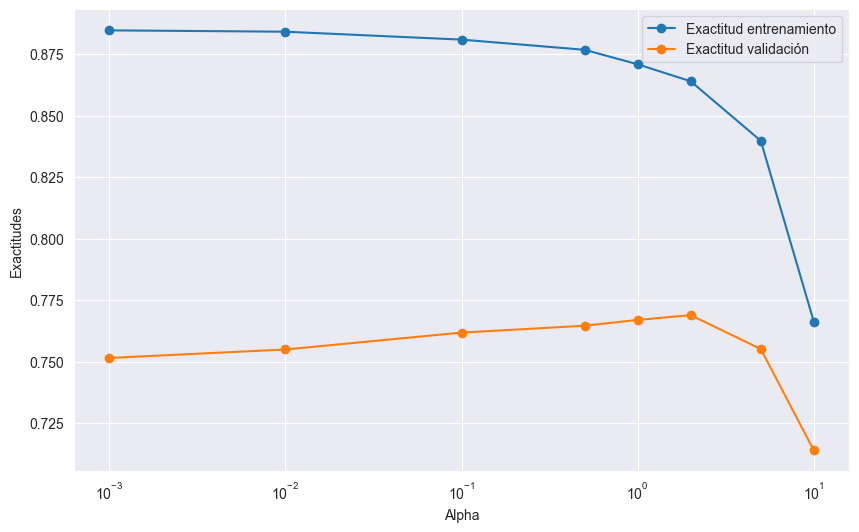

In [231]:
# TODO: Visualizar el efecto de alpha
#
# Instrucciones:
# 1. Grafique train_scores y test_scores vs alphas
# 2. Use plt.xscale('log') para escala logarítmica
# 3. Agregue leyenda, título y etiquetas
plt.plot(resultado_alphas["alphas"],
         resultado_alphas["exactitudes_entrenamiento"],
         marker="o",
         label="Exactitud entrenamiento")

plt.plot(resultado_alphas["alphas"],
         resultado_alphas["exactitudes_validacion"],
         marker="o",
         label="Exactitud validación")

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Exactitudes")
plt.legend()
plt.show()

### Pregunta 6: Efecto de Alpha
¿Qué ocurre cuando alpha es muy pequeño (ej: 0.001)?

A) El modelo generaliza mejor  
B) El modelo tiende a sobreajustar (train acc >> test acc)  
C) El modelo no aprende nada  
D) No hay efecto significativo  

**Su Respuesta:** B

## Parte 7: N-gramas

### Teoría:
Los **n-gramas** capturan secuencias de n palabras consecutivas:
- Unigrama (1-gram): palabras individuales
- Bigrama (2-gram): pares de palabras
- Trigrama (3-gram): tríos de palabras

Ejemplo: "I love this movie"
- Unigramas: ["I", "love", "this", "movie"]
- Bigramas: ["I love", "love this", "this movie"]

In [232]:
# TODO: Experimentar con diferentes n-gramas
#
# Instrucciones:
# 1. Defina ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
# 2. Para cada configuración:
#    a. Cree CountVectorizer(ngram_range=ngram, min_df=5)
#    b. Use make_xy() para crear X, y
#    c. Divida en train/test
#    d. Entrene MultinomialNB y calcule precisiones
# 3. Imprima los resultados comparativos

ngramas_configuraciones = [(1,1), (1,2), (2,2), (1,3), (2,3)]
precisiones_entrenamiento_ngramas= []
precisiones_validacion_ngramas= []
for n_grama in ngramas_configuraciones:
    vectorizador_ngramas = CountVectorizer(ngram_range=n_grama, min_df=5)
    x_ngramas, y_ngramas = make_xy(data= df_critics, vectorizer= vectorizador_ngramas)
    x_entrenamiento_ngrama, x_validacion_ngrama, y_entrenamiento_ngrama, y_validacion_ngrama = train_test_split(x_ngramas, y_ngramas,  test_size=0.3, random_state=42)
    modelo_ngrama = MultinomialNB()
    modelo_ngrama.fit(X= x_entrenamiento_ngrama, y= y_entrenamiento_ngrama)
    y_predicciones_validacion_ngrama = modelo_ngrama.predict(X= x_validacion_ngrama)
    y_predicciones_entrenamiento_ngrama = modelo_ngrama.predict(X= x_entrenamiento_ngrama)
    precision_entrenamiento_ngrama= precision_score(y_true= y_entrenamiento_ngrama, y_pred= y_predicciones_entrenamiento_ngrama)
    precisiones_entrenamiento_ngramas.append(precision_entrenamiento_ngrama)
    precision_validacion_ngrama= precision_score(y_true= y_validacion_ngrama, y_pred= y_predicciones_validacion_ngrama)
    precisiones_validacion_ngramas.append(precision_validacion_ngrama)
diccionario_resultados_ngramas = {
    "Ngrama": ngramas_configuraciones,
    "Precision_validacion": precisiones_validacion_ngramas,
    "Precision_entrenamiento": precisiones_entrenamiento_ngramas,
}
precisiones_n_gramas = pd.DataFrame(data= diccionario_resultados_ngramas)
precisiones_n_gramas

,Ngrama,Precision_validacion,Precision_entrenamiento
0,"(1, 1)",0.802250,0.892347
1,"(1, 2)",0.817989,0.920730
2,"(2, 2)",0.729370,0.828348
3,"(1, 3)",0.815714,0.920449
4,"(2, 3)",0.726281,0.831185


### Pregunta 7: N-gramas
¿Qué ocurre al usar solo bigramas (2,2) en comparación con unigramas (1,1)?

A) Siempre mejora la precisión  
B) Aumenta mucho el número de características y puede sobreajustar  
C) Reduce el número de características  
D) No tiene ningún efecto  

**Su Respuesta:** B

## Parte 8: TF-IDF

### Teoría:
**TF-IDF** (Term Frequency - Inverse Document Frequency) pondera las palabras por su importancia:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

Donde:
- TF(t,d): Frecuencia del término t en el documento d
- IDF(t): log(N / df(t)) - penaliza palabras muy comunes

In [233]:
# TODO: Aplicar TF-IDF
#
# Instrucciones:
# 1. Cree tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
# 2. Use make_xy() para crear X_tfidf, y_tfidf
# 3. Divida en train/test
# 4. Entrene MultinomialNB
# 5. Calcule y muestre precisiones train/test

vectorizador_tfidf = TfidfVectorizer(min_df=5, stop_words='english')
x_tfidf, y_tfidf = make_xy(data= df_critics, vectorizer= vectorizador_tfidf)
x_entrenamiento_tfidf, x_validacion_tfidf, y_entrenamiento_tfidf, y_validacion_tfidf = train_test_split(x_tfidf, y_tfidf,  test_size=0.3, random_state=42)
modelo_tfidf = MultinomialNB()
modelo_tfidf.fit(X=x_entrenamiento_tfidf , y=y_entrenamiento_tfidf)
y_predicciones_validacion_tfidfg = modelo_tfidf.predict(X= x_validacion_tfidf)
y_predicciones_entrenamiento_tfidfg = modelo_tfidf.predict(X= x_entrenamiento_tfidf)
precision_entrenamiento_tfidfg = precision_score(y_pred = y_predicciones_entrenamiento_tfidfg, y_true= y_entrenamiento_tfidf)
precision_validacion_tfidfg = precision_score(y_pred = y_predicciones_validacion_tfidfg, y_true= y_validacion_tfidf)
print(f"precision_entrenamiento: {precision_entrenamiento_tfidfg}\n"
      f"precision_validacion: {precision_validacion_tfidfg}")

precision_entrenamiento: 0.8153767690934591
precision_validacion: 0.7299695037427225


In [234]:
# TODO: Imprimir reporte de clasificación con TF-IDF
#
# Instrucciones:
# 1. Prediga con el modelo TF-IDF
# 2. Use classification_report() para el reporte
reporte_clasificacion_tfidf = classification_report(y_true= y_validacion_tfidf, y_pred= y_predicciones_validacion_tfidfg, target_names= ["Rotten", "Fresh"] )
print(reporte_clasificacion_tfidf)

              precision    recall  f1-score   support

      Rotten       0.79      0.46      0.58      1802
       Fresh       0.73      0.92      0.81      2859

    accuracy                           0.74      4661
   macro avg       0.76      0.69      0.70      4661
weighted avg       0.75      0.74      0.72      4661



### Pregunta 8: TF-IDF vs CountVectorizer
¿Cuál es una ventaja de TF-IDF sobre CountVectorizer simple?

A) Siempre da mejor precisión  
B) Penaliza palabras muy comunes y reduce el sobreajuste  
C) Usa menos memoria  
D) Es más rápido de calcular  

**Su Respuesta:** B

## Parte 9: Interpretación del Modelo

In [235]:
# TODO: Identificar las palabras más predictivas
#
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

feature_names = np.array(vectorizador.get_feature_names_out())
log_probabilidades_fresh = modelo_clasificador_multinomial.feature_log_prob_[1]
log_probabilidades_rotten= modelo_clasificador_multinomial.feature_log_prob_[0]
log_rango = log_probabilidades_fresh - log_probabilidades_rotten
indices_negativos = log_rango.argsort()[:15]
for indice in indices_negativos:
    print(feature_names[indice], log_rango[indice])
print()

indices_positivos = log_rango.argsort()[-15:]
for indice in reversed(indices_positivos):
    print(feature_names[indice], log_rango[indice])

lame -3.5282727612950744
pointless -3.3816692871031986
uninspired -3.2704436519929736
unfortunately -3.20981903017654
unfunny -2.835125580735129
witless -2.835125580735129
charmless -2.739815400930805
repetitive -2.739815400930805
monotonous -2.739815400930805
resembles -2.739815400930805
forgettable -2.739815400930805
unsatisfying -2.739815400930805
bland -2.6708225294438535
fault -2.6344548852729783
besson -2.6344548852729783

delight 3.1462886305193507
superb 2.894974202238446
richly 2.6072921297866642
bold 2.6072921297866642
captures 2.558501965617232
rousing 2.507208671229682
gentle 2.507208671229682
innocence 2.507208671229682
winning 2.453141449959407
intimate 2.453141449959407
touching 2.3559777015057595
irresistible 2.3353584143030233
kurosawa 2.3353584143030233
myth 2.3353584143030233
childhood 2.270819893165452


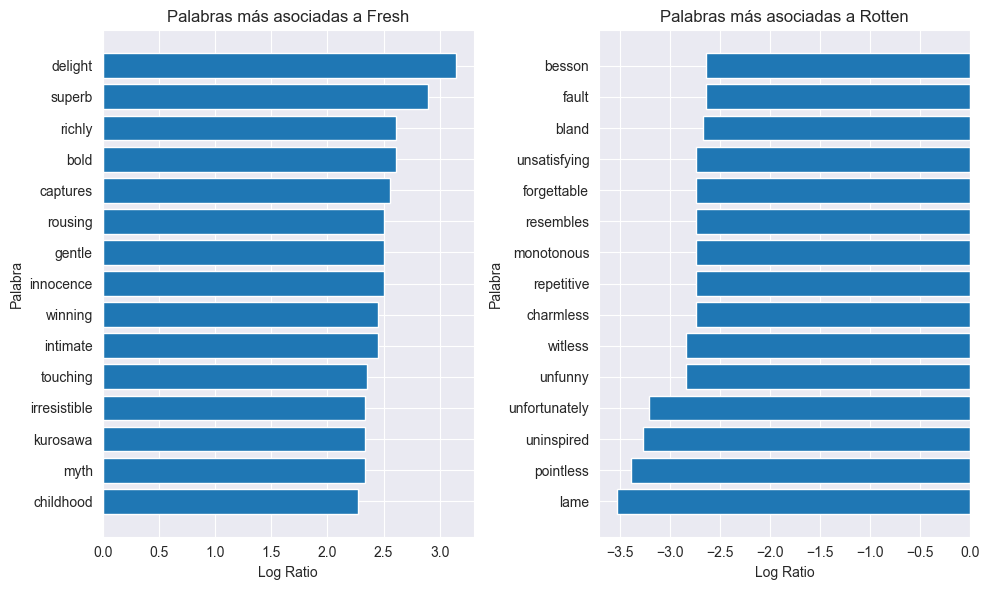

In [236]:
# TODO: Visualizar las palabras más predictivas
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, grafique las palabras más positivas con barh()
# 3. En el segundo subplot, grafique las palabras más negativas
# 4. Agregue títulos y etiquetas

fugura, axes= plt.subplots(nrows=1, ncols= 2)
palabras_positivas = feature_names[indices_positivos]
valores_positivos = log_rango[indices_positivos]

palabras_negativas = feature_names[indices_negativos]
valores_negativos = log_rango[indices_negativos]
# Palabras positivas
axes[0].barh(palabras_positivas, valores_positivos)
axes[0].set_title("Palabras más asociadas a Fresh")
axes[0].set_xlabel("Log Ratio")
axes[0].set_ylabel("Palabra")

axes[1].barh(palabras_negativas, valores_negativos)
axes[1].set_title("Palabras más asociadas a Rotten")
axes[1].set_xlabel("Log Ratio")
axes[1].set_ylabel("Palabra")
plt.tight_layout()
plt.show()

### Pregunta 9: Interpretabilidad
¿Qué tipo de palabras esperaría encontrar asociadas a reseñas negativas?

A) Palabras como "excellent", "amazing", "brilliant"  
B) Palabras como "boring", "bad", "disappointing"  
C) Palabras neutrales como "the", "and", "is"  
D) Nombres de actores  

**Su Respuesta:** B

## Parte 10: Predicción con Nuevas Reseñas

In [237]:
# TODO: Probar el modelo con nuevas reseñas
#
# Instrucciones:
# 1. Defina una lista de nuevas reseñas de ejemplo
# 2. Transforme con vectorizer.transform(new_reviews)
# 3. Prediga con clf_nb.predict()
# 4. Obtenga probabilidades con clf_nb.predict_proba()
# 5. Imprima cada reseña con su predicción y probabilidades

new_reviews = [
    "This movie is absolutely amazing! Best film of the year!",
    "Terrible waste of time. Boring and predictable.",
    "A decent film with good performances but weak plot.",
    "Masterpiece! Incredible acting and stunning visuals.",
    "I've seen better. Nothing special about this one."
]

# Su código aquí
new_reviews_vectorizado= vectorizador.transform(new_reviews)
y_predicciones_multinomial_new_reviews= modelo_clasificador_multinomial.predict(new_reviews_vectorizado)
y_predicciones_proba_multinomial_new_reviews = modelo_clasificador_multinomial.predict_proba(new_reviews_vectorizado)[:, 1]

diccionario_resena_prediccion_probabilidad = {
    "Reseña": new_reviews,
    "Prediccición": y_predicciones_multinomial_new_reviews,
    "Probabilidad": y_predicciones_proba_multinomial_new_reviews
}
tabla_resena_prediccion_probabilidad_multinomial = pd.DataFrame(data= diccionario_resena_prediccion_probabilidad)
tabla_resena_prediccion_probabilidad_multinomial


,Reseña,Prediccición,Probabilidad
0,This movie is absolutely amazing! Best film of...,1,0.975089
1,Terrible waste of time. Boring and predictable.,0,0.015169
2,A decent film with good performances but weak ...,1,0.547642
3,Masterpiece! Incredible acting and stunning vi...,1,0.995060
4,I've seen better. Nothing special about this one.,0,0.342682


### Pregunta 10: Predicciones
¿Qué método se usa para obtener las probabilidades de cada clase?

A) predict()  
B) predict_proba()  
C) score()  
D) fit()  

**Su Respuesta:** B

## Parte 11: Comparación de Modelos

Funcion Metricas

In [238]:
def metricas_clasificacion_binaria(y_true, y_pred, nombre_modelo, etiqueta_calcular ):
    exactitud = accuracy_score(y_true = y_true, y_pred= y_pred)
    presicion = precision_score(y_true = y_true, y_pred= y_pred, pos_label = etiqueta_calcular )
    recall = recall_score(y_true = y_true, y_pred= y_pred, pos_label= etiqueta_calcular)
    f1= f1_score(y_true = y_true, y_pred= y_pred, pos_label= etiqueta_calcular)

    return pd.DataFrame(data=[[exactitud, presicion, recall, f1]], columns=[["exactitud", "presicion", "recall", "f1"]], index= [nombre_modelo]).T

In [239]:
# TODO: Comparar Multinomial vs Bernoulli Naive Bayes
#
# Instrucciones:
# 1. Cree y entrene BernoulliNB() con los mismos datos
# 2. Calcule precisiones train/test
# 3. Cree un DataFrame comparando:
#    - Multinomial NB
#    - Bernoulli NB
#    - Multinomial + TF-IDF
# 4. Imprima la tabla comparativa

modelo_clasificador_bernoulli = BernoulliNB()
modelo_clasificador_bernoulli.fit(X= x_entrenamiento_general.toarray(), y=y_entrenamiento_general)
y_predicciones_entrenamiento_bernoulli = modelo_clasificador_bernoulli.predict(X= x_entrenamiento_general.toarray())
y_predicciones_validacion_bernoulli = modelo_clasificador_bernoulli.predict(X= x_validacion_general.toarray())
presicion_entrenamiento_bernoulli= precision_score(y_pred= y_predicciones_entrenamiento_bernoulli, y_true= y_entrenamiento_general)
presicion_validacion_bernoulli = precision_score(y_pred= y_predicciones_validacion_bernoulli, y_true= y_validacion_general)

print("presicion_entrenamiento: ", presicion_entrenamiento_bernoulli)
print("presicion_validacion: ", presicion_validacion_bernoulli)

presicion_entrenamiento:  0.89035350509287
presicion_validacion:  0.8040885860306644


In [240]:
metricas_multinomial = metricas_clasificacion_binaria(y_true= y_validacion_general, y_pred= y_predicciones_validacion_multinomial, nombre_modelo= "Multinomial", etiqueta_calcular= 1)

metricas_bernoulli = metricas_clasificacion_binaria(y_true= y_validacion_general, y_pred= y_predicciones_validacion_bernoulli, nombre_modelo= "Bernoulli", etiqueta_calcular= 1)

metricas_multinomial_tfidf = metricas_clasificacion_binaria(y_true= y_validacion_general, y_pred= y_predicciones_validacion_tfidfg, nombre_modelo= "Multinomial_tfidf", etiqueta_calcular= 1)

tabla_comparativa = pd.concat(objs=[metricas_multinomial, metricas_bernoulli, metricas_multinomial_tfidf], axis=1)
tabla_comparativa

,Multinomial,Bernoulli,Multinomial_tfidf
exactitud,0.767003,0.769577,0.742545
presicion,0.802250,0.804089,0.729970
recall,0.823015,0.825463,0.920951
f1,0.812500,0.814636,0.814414


### Pregunta 11: Multinomial vs Bernoulli
¿Cuál es la diferencia principal entre Multinomial y Bernoulli Naive Bayes?

A) No hay diferencia  
B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria  
C) Bernoulli es siempre mejor  
D) Multinomial solo funciona con TF-IDF  

**Su Respuesta:** B

### Pregunta 12: Suposición de Naive Bayes
¿Cuál es la suposición principal del algoritmo Naive Bayes?

A) Las características tienen distribución normal  
B) Las características son independientes dada la clase  
C) Los datos deben estar normalizados  
D) Debe haber balance de clases  

**Su Respuesta:** B

### Pregunta 13: Ventajas de Naive Bayes
¿Cuál es una ventaja de Naive Bayes para clasificación de texto?

A) Siempre da la mejor precisión  
B) Es rápido de entrenar y funciona bien con alta dimensionalidad  
C) No requiere preprocesamiento  
D) Captura relaciones complejas entre palabras  

**Su Respuesta:** B

### Pregunta 14: Stop Words
¿Qué son las "stop words" en procesamiento de texto?

A) Palabras con errores ortográficos  
B) Palabras muy comunes que aportan poca información (the, is, and)  
C) Palabras negativas  
D) Palabras técnicas  

**Su Respuesta:** B

### Pregunta 15: min_df en CountVectorizer
¿Qué hace el parámetro min_df=5 en CountVectorizer?

A) Limita a 5 palabras por documento  
B) Ignora palabras que aparecen en menos de 5 documentos  
C) Usa solo las 5 palabras más frecuentes  
D) Divide los datos en 5 partes  

**Su Respuesta:** B

## ¡Excelente Trabajo!

Responda las preguntas basadas en sus ejecuciones. Entregue el notebook completado con todas las celdas ejecutadas.